# RQ1 - Effectiveness & Efficiency

Final figures and tables for comparing MetaSpace against schema-matching baselines.

Effectiveness protocol: all-to-all F1/precision/recall are computed for each table pair, then averaged over the available table pairs.

Efficiency protocol: offline/preliminary costs are separated from application-time costs. For MetaSpace, preliminary computation includes 60 meta-feature construction and Random Forest training; application time only includes RF `predict_proba` on the test rows.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from IPython.display import display

OUT = Path(r"/Users/nahawandkired/Documents/metamatch/outputs/exp_occidata/reports/meeting_baselines_vs_metamatch/rq1_effectiveness_efficiency")
OUT.mkdir(parents=True, exist_ok=True)
(OUT / "companion_site_csv").mkdir(parents=True, exist_ok=True)

FINAL_BASELINES_PAIR = Path(r"/Users/nahawandkired/Documents/metamatch/outputs/final_consolidated_baselines_FULL/final_all_results_pair_level.csv")
METASPACE_OPT_PAIR = Path(r"/Users/nahawandkired/Documents/metamatch/outputs/exp_occidata/reports/meeting_baselines_vs_metamatch/effectiveness_all_to_all_OPT_PAIRF1_TRAIN_FAST_all_metaspace_classifiers_plus_llmatch/metaspace_all_to_all_OPT_PAIRF1_TRAIN_FAST_by_pair.csv")
METASPACE_OPT_SUMMARY = Path(r"/Users/nahawandkired/Documents/metamatch/outputs/exp_occidata/reports/meeting_baselines_vs_metamatch/effectiveness_all_to_all_OPT_PAIRF1_TRAIN_FAST_all_metaspace_classifiers_plus_llmatch/metaspace_all_to_all_OPT_PAIRF1_TRAIN_FAST_summary.csv")

plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

METHOD_PALETTE = {
    "MetaSpace": "#D62828",
    "LLMATCH": "#7B2CBF",
    "MagnetoFTGPT": "#C2410C",
    "MagnetoGPT": "#F59F00",
    "SMUTF": "#2F9E44",
    "MagnetoFT": "#E67700",
    "COMA++": "#4DABF7",
    "Magneto": "#F08C00",
    "COMA": "#A5D8FF",
    "Similarity Flooding": "#15AABF",
    "ISResMat": "#1C7ED6",
    "Cupid": "#495057",
    "Distribution Based": "#868E96",
}

CLASSIFIER_PALETTE = {
    "MetaSpace Random Forest": "#D62828",
    "MetaSpace XGBoost": "#F08C00",
    "MetaSpace CatBoost": "#7B2CBF",
    "MetaSpace Logistic Regression": "#1C7ED6",
    "MetaSpace SVM": "#2F9E44",
}

PLOT_ORDER = [
    "MetaSpace", "LLMATCH", "MagnetoFTGPT", "MagnetoGPT", "SMUTF", "MagnetoFT", "COMA++",
    "Magneto", "COMA", "Similarity Flooding", "ISResMat", "Cupid", "Distribution Based",
]

METHOD_RENAME = {
    "LLMatch-llm": "LLMATCH",
    "Distribution": "Distribution Based",
}

def method_color(method):
    return METHOD_PALETTE.get(method, CLASSIFIER_PALETTE.get(method, "#666666"))

def save_fig(fig, stem):
    png = OUT / f"{stem}.png"
    pdf = OUT / f"{stem}.pdf"
    fig.savefig(png, bbox_inches="tight")
    fig.savefig(pdf, bbox_inches="tight")
    print("Saved:", png)
    print("Saved:", pdf)
    return png, pdf

def legend_for_methods(methods, ncol=7):
    return [mpatches.Patch(color=method_color(m), label=m) for m in methods]

def format_pm(mean, std):
    return f"{mean:.2f} $\\pm$ {std:.2f}"


def canonical_pair_id(value):
    s = str(value)
    parts = s.split("__")
    if len(parts) >= 3 and parts[1].endswith("_source.csv"):
        s = parts[1]
    elif len(parts) >= 3 and parts[1].endswith(".csv"):
        s = parts[1]
    elif len(parts) >= 3:
        s = "__".join(parts[2:])
    elif len(parts) == 2 and parts[1].endswith(".csv"):
        s = parts[1]
    return s.replace("_source.csv", "").replace("_target.csv", "").replace(".csv", "")




In [2]:
# Build paper-ready pair-level files from final consolidated baselines + optimized MetaSpace RF60.
baselines = pd.read_csv(FINAL_BASELINES_PAIR).copy()
baselines["method"] = baselines["method"].replace(METHOD_RENAME)
baselines = baselines[baselines["method"].isin([m for m in PLOT_ORDER if m != "MetaSpace"])].copy()
baselines_pair = baselines.rename(columns={
    "precision": "precision_all_to_all",
    "recall": "recall_all_to_all",
})[["method", "pair_id", "f1_all_to_all", "precision_all_to_all", "recall_all_to_all", "runtime", "scenario", "source_file"]]
baselines_pair["method_raw"] = baselines_pair["method"]
baselines_pair["pair_id_raw"] = baselines_pair["pair_id"]
baselines_pair["source"] = baselines_pair["source_file"]
baselines_pair = baselines_pair.drop(columns=["source_file"])

meta_all = pd.read_csv(METASPACE_OPT_PAIR).copy()
meta = meta_all[meta_all["method"] == "MetaSpace RF"].copy()
meta_pair = pd.DataFrame({
    "method": "MetaSpace",
    "method_raw": meta["method"],
    "pair_id": meta["pair_id"],
    "pair_id_raw": meta["pair_id"],
    "f1_all_to_all": meta["f1_all_to_all"],
    "precision_all_to_all": meta["precision_all_to_all"],
    "recall_all_to_all": meta["recall_all_to_all"],
    "runtime": meta["runtime"],
    "scenario": meta["scenario"],
    "source": meta["source"],
})

pair_ready = pd.concat([meta_pair, baselines_pair], ignore_index=True, sort=False)
pair_ready = pair_ready[["method", "method_raw", "pair_id", "pair_id_raw", "f1_all_to_all", "precision_all_to_all", "recall_all_to_all", "runtime", "scenario", "source"]]
pair_ready["pair_id_canonical"] = pair_ready["pair_id"].map(canonical_pair_id)
pair_ready.to_csv(OUT / "effectiveness_baselines_metaspace_by_pair.csv", index=False)
pair_ready.to_csv(OUT / "companion_site_csv/figure_2_effectiveness_baselines_metaspace_by_pair.csv", index=False)

summary = (
    pair_ready.groupby("method", as_index=False)
    .agg(
        f1_mean=("f1_all_to_all", "mean"),
        f1_std=("f1_all_to_all", "std"),
        precision_mean=("precision_all_to_all", "mean"),
        precision_std=("precision_all_to_all", "std"),
        recall_mean=("recall_all_to_all", "mean"),
        recall_std=("recall_all_to_all", "std"),
        n_pairs=("pair_id_canonical", "nunique"),
    )
)
summary["order"] = summary["method"].map({m: i for i, m in enumerate(PLOT_ORDER)})
summary = summary.sort_values(["f1_mean", "order"], ascending=[False, True]).drop(columns="order")
summary.to_csv(OUT / "effectiveness_baselines_metaspace_summary.csv", index=False)
summary.to_csv(OUT / "companion_site_csv/table_1_effectiveness_baselines_summary.csv", index=False)

ms_summary = pd.read_csv(METASPACE_OPT_SUMMARY).copy()
name_map = {
    "MetaSpace RF": "MetaSpace Random Forest",
    "MetaSpace XGBoost": "MetaSpace XGBoost",
    "MetaSpace CatBoost": "MetaSpace CatBoost",
    "MetaSpace SVM": "MetaSpace SVM",
    "MetaSpace LogReg": "MetaSpace Logistic Regression",
}
classifier = pd.DataFrame({
    "method": ms_summary["method"].replace(name_map),
    "f1_mean": ms_summary["mean_f1_all_to_all"],
    "f1_std": ms_summary["std_f1_all_to_all"],
    "precision_mean": ms_summary["mean_precision_all_to_all"],
    "recall_mean": ms_summary["mean_recall_all_to_all"],
    "n_pair_id": ms_summary["n_pair_id"],
})
stds = meta_all.groupby("method", as_index=False).agg(
    precision_std=("precision_all_to_all", "std"),
    recall_std=("recall_all_to_all", "std"),
)
stds["method"] = stds["method"].replace(name_map)
classifier = classifier.merge(stds, on="method", how="left").sort_values("f1_mean", ascending=False)
classifier.to_csv(OUT / "metaspace_classifiers_metrics_mean_std.csv", index=False)
classifier.to_csv(OUT / "companion_site_csv/table_1_metaspace_classifiers_all_to_all.csv", index=False)

runtime_ready = baselines_pair[["method", "pair_id", "runtime"]].rename(columns={"runtime": "runtime_sec_pair"}).copy()
runtime_ready["runtime_note"] = "final consolidated runtime per table pair"
old_runtime = OUT / "efficiency_runtime_by_pair.csv"
if old_runtime.exists():
    old = pd.read_csv(old_runtime)
    old_meta = old[old["method"] == "MetaSpace"][["method", "pair_id", "runtime_sec_pair", "runtime_note"]]
    runtime_ready = pd.concat([old_meta, runtime_ready], ignore_index=True)
runtime_ready.to_csv(OUT / "efficiency_runtime_by_pair.csv", index=False)
runtime_ready.to_csv(OUT / "companion_site_csv/figure_4_distribution_application_runtime_by_pair.csv", index=False)

display(summary.round(2))
print("Saved optimized pair-level, summary, classifier, and runtime CSVs in", OUT)


,method,f1_mean,f1_std,precision_mean,precision_std,recall_mean,recall_std,n_pairs
5,LLMATCH,0.85,0.25,0.84,0.28,0.93,0.18,551
10,MetaSpace,0.81,0.24,0.80,0.26,0.84,0.24,551
8,MagnetoFTGPT,0.74,0.25,0.76,0.30,0.85,0.19,551
9,MagnetoGPT,0.72,0.29,0.70,0.33,0.90,0.15,551
11,SMUTF,0.72,0.27,0.74,0.31,0.77,0.26,551
7,MagnetoFT,0.61,0.27,0.56,0.29,0.80,0.23,551
1,COMA++,0.59,0.24,0.79,0.32,0.56,0.28,509
6,Magneto,0.58,0.29,0.51,0.30,0.84,0.20,551
0,COMA,0.51,0.26,0.73,0.34,0.49,0.31,544
12,Similarity Flooding,0.50,0.35,0.47,0.35,0.68,0.39,543


Saved optimized pair-level, summary, classifier, and runtime CSVs in /Users/nahawandkired/Documents/metamatch/outputs/exp_occidata/reports/meeting_baselines_vs_metamatch/rq1_effectiveness_efficiency


## 1. MetaSpace Classifiers: All-To-All Metrics


In [3]:
classifier = pd.read_csv(OUT / "metaspace_classifiers_metrics_mean_std.csv")
classifier = classifier.sort_values("f1_mean", ascending=False).reset_index(drop=True)

classifier_table_paper = pd.DataFrame({
    "Classifier": classifier["method"].str.replace("MetaSpace ", "", regex=False),
    "F1": [format_pm(m, s) for m, s in zip(classifier["f1_mean"], classifier["f1_std"])],
    "Precision": [format_pm(m, s) for m, s in zip(classifier["precision_mean"], classifier["precision_std"])],
    "Recall": [format_pm(m, s) for m, s in zip(classifier["recall_mean"], classifier["recall_std"])],
})

display(classifier_table_paper)

latex_code = classifier_table_paper.to_latex(index=False, escape=False)
latex_path = OUT / "table_metaspace_classifiers_all_to_all_latex.tex"
latex_path.write_text(latex_code)
print(latex_code)
print("Saved:", latex_path)



,Classifier,F1,Precision,Recall
0,Random Forest,0.81 $\pm$ 0.24,0.80 $\pm$ 0.26,0.84 $\pm$ 0.24
1,XGBoost,0.65 $\pm$ 0.26,0.73 $\pm$ 0.28,0.64 $\pm$ 0.30
2,CatBoost,0.61 $\pm$ 0.26,0.65 $\pm$ 0.28,0.65 $\pm$ 0.31
3,SVM,0.50 $\pm$ 0.25,0.56 $\pm$ 0.28,0.55 $\pm$ 0.31
4,Logistic Regression,0.50 $\pm$ 0.25,0.56 $\pm$ 0.28,0.54 $\pm$ 0.31


\begin{tabular}{llll}
\toprule
Classifier & F1 & Precision & Recall \\
\midrule
Random Forest & 0.81 $\pm$ 0.24 & 0.80 $\pm$ 0.26 & 0.84 $\pm$ 0.24 \\
XGBoost & 0.65 $\pm$ 0.26 & 0.73 $\pm$ 0.28 & 0.64 $\pm$ 0.30 \\
CatBoost & 0.61 $\pm$ 0.26 & 0.65 $\pm$ 0.28 & 0.65 $\pm$ 0.31 \\
SVM & 0.50 $\pm$ 0.25 & 0.56 $\pm$ 0.28 & 0.55 $\pm$ 0.31 \\
Logistic Regression & 0.50 $\pm$ 0.25 & 0.56 $\pm$ 0.28 & 0.54 $\pm$ 0.31 \\
\bottomrule
\end{tabular}

Saved: /Users/nahawandkired/Documents/metamatch/outputs/exp_occidata/reports/meeting_baselines_vs_metamatch/rq1_effectiveness_efficiency/table_metaspace_classifiers_all_to_all_latex.tex


## 2. Pairwise Win Rate: Methods vs. Methods



Saved: /Users/nahawandkired/Documents/metamatch/outputs/exp_occidata/reports/meeting_baselines_vs_metamatch/rq1_effectiveness_efficiency/plot_winrate_f1_all_to_all_no_ties_matplotlib_percent_heatmap.png
Saved: /Users/nahawandkired/Documents/metamatch/outputs/exp_occidata/reports/meeting_baselines_vs_metamatch/rq1_effectiveness_efficiency/plot_winrate_f1_all_to_all_no_ties_matplotlib_percent_heatmap.pdf


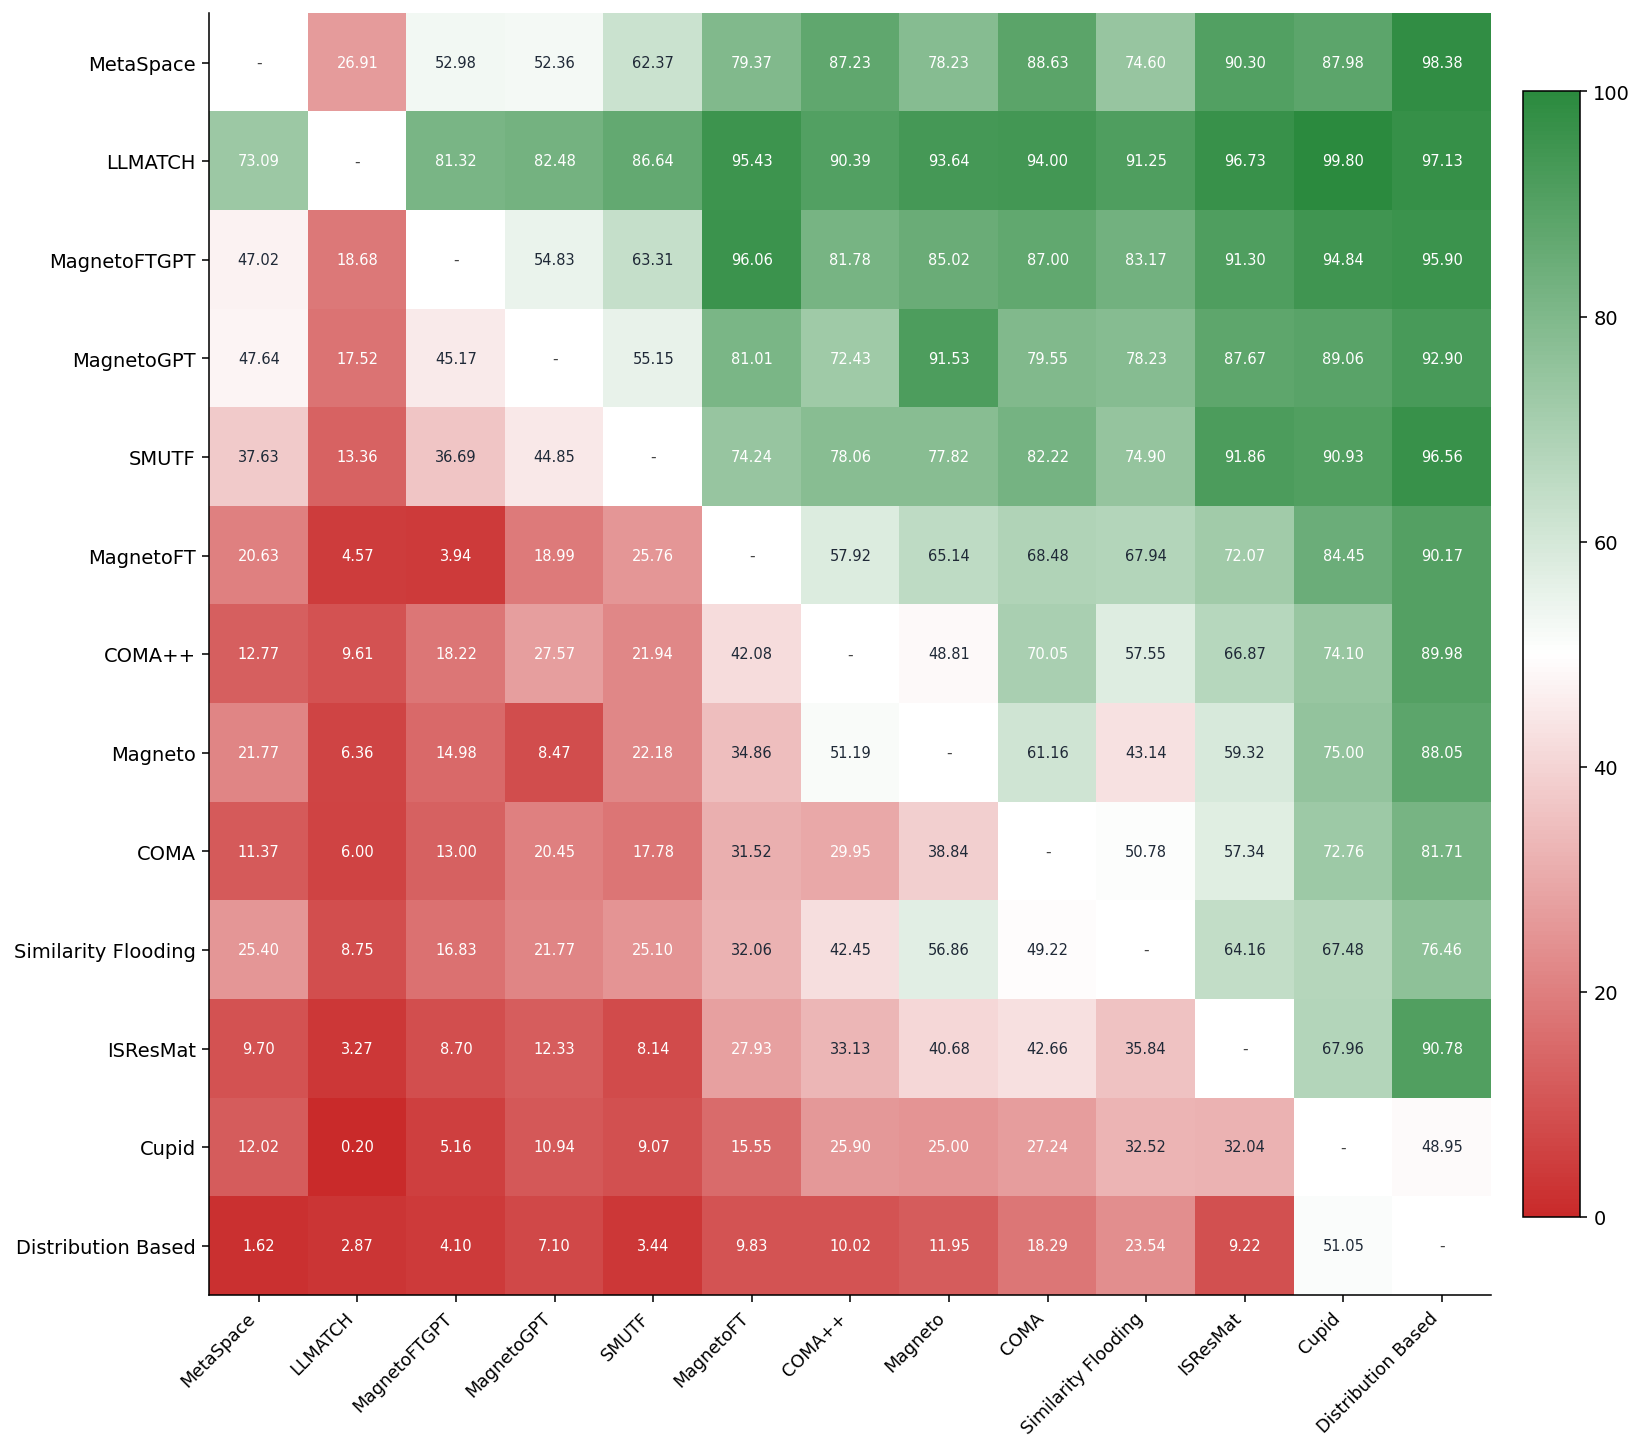

Saved: /Users/nahawandkired/Documents/metamatch/outputs/exp_occidata/reports/meeting_baselines_vs_metamatch/rq1_effectiveness_efficiency/winrate_f1_all_to_all_no_ties_percent_matrix.csv
Saved: /Users/nahawandkired/Documents/metamatch/outputs/exp_occidata/reports/meeting_baselines_vs_metamatch/rq1_effectiveness_efficiency/winrate_f1_all_to_all_tie_count_matrix.csv
Saved: /Users/nahawandkired/Documents/metamatch/outputs/exp_occidata/reports/meeting_baselines_vs_metamatch/rq1_effectiveness_efficiency/winrate_f1_all_to_all_common_support_matrix.csv


In [4]:
pair_f1_for_win = pd.read_csv(OUT / "effectiveness_baselines_metaspace_by_pair.csv")
pair_f1_for_win = pair_f1_for_win[pair_f1_for_win["method"].isin(PLOT_ORDER)].copy()
pair_f1_for_win["f1_all_to_all"] = pd.to_numeric(pair_f1_for_win["f1_all_to_all"], errors="coerce")
if "pair_id_canonical" not in pair_f1_for_win.columns:
    pair_f1_for_win["pair_id_canonical"] = pair_f1_for_win["pair_id"].map(canonical_pair_id)

wide = (
    pair_f1_for_win
    .dropna(subset=["f1_all_to_all"])
    .sort_values(["method", "pair_id_canonical", "f1_all_to_all"], ascending=[True, True, False])
    .drop_duplicates(["method", "pair_id_canonical"], keep="first")
    .pivot(index="pair_id_canonical", columns="method", values="f1_all_to_all")
)
methods = [m for m in PLOT_ORDER if m in wide.columns]

win = pd.DataFrame(np.nan, index=methods, columns=methods, dtype=float)
ties = pd.DataFrame(0, index=methods, columns=methods, dtype=int)
support = pd.DataFrame(0, index=methods, columns=methods, dtype=int)

for a in methods:
    for b in methods:
        if a == b:
            continue
        sub = wide[[a, b]].dropna()
        wins = int((sub[a] > sub[b]).sum())
        losses = int((sub[a] < sub[b]).sum())
        tie_count = int((sub[a] == sub[b]).sum())
        denom = wins + losses
        win.loc[a, b] = np.nan if denom == 0 else 100 * wins / denom
        ties.loc[a, b] = tie_count
        support.loc[a, b] = len(sub)

win = win.round(2)
win.to_csv(OUT / "winrate_f1_all_to_all_no_ties_percent_matrix.csv")
ties.to_csv(OUT / "winrate_f1_all_to_all_tie_count_matrix.csv")
support.to_csv(OUT / "winrate_f1_all_to_all_common_support_matrix.csv")

cmap = LinearSegmentedColormap.from_list("red_white_green", ["#C92A2A", "#FFFFFF", "#2B8A3E"])
masked = np.ma.masked_invalid(win.to_numpy())

fig, ax = plt.subplots(figsize=(12.5, 10.5))
im = ax.imshow(masked, cmap=cmap, vmin=0, vmax=100)
ax.set_xticks(np.arange(len(methods)))
ax.set_yticks(np.arange(len(methods)))
ax.set_xticklabels(methods, rotation=45, ha="right")
ax.set_yticklabels(methods)
ax.set_xlabel("")
ax.set_ylabel("")

for i in range(len(methods)):
    for j in range(len(methods)):
        if i == j or pd.isna(win.iloc[i, j]):
            ax.text(j, i, "-", ha="center", va="center", color="#444444", fontsize=8)
        else:
            value = win.iloc[i, j]
            color = "white" if value < 30 or value > 70 else "#1f2937"
            ax.text(j, i, f"{value:.2f}", ha="center", va="center", color=color, fontsize=7.5)

cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
cbar.set_label("")
fig.tight_layout()
save_fig(fig, "plot_winrate_f1_all_to_all_no_ties_matplotlib_percent_heatmap")
plt.show()

print("Saved:", OUT / "winrate_f1_all_to_all_no_ties_percent_matrix.csv")
print("Saved:", OUT / "winrate_f1_all_to_all_tie_count_matrix.csv")
print("Saved:", OUT / "winrate_f1_all_to_all_common_support_matrix.csv")



## 3. F1 All-To-All Distribution by Table Pair


Saved: /Users/nahawandkired/Documents/metamatch/outputs/exp_occidata/reports/meeting_baselines_vs_metamatch/rq1_effectiveness_efficiency/plot_distribution_f1_all_to_all_by_method_matplotlib.png
Saved: /Users/nahawandkired/Documents/metamatch/outputs/exp_occidata/reports/meeting_baselines_vs_metamatch/rq1_effectiveness_efficiency/plot_distribution_f1_all_to_all_by_method_matplotlib.pdf


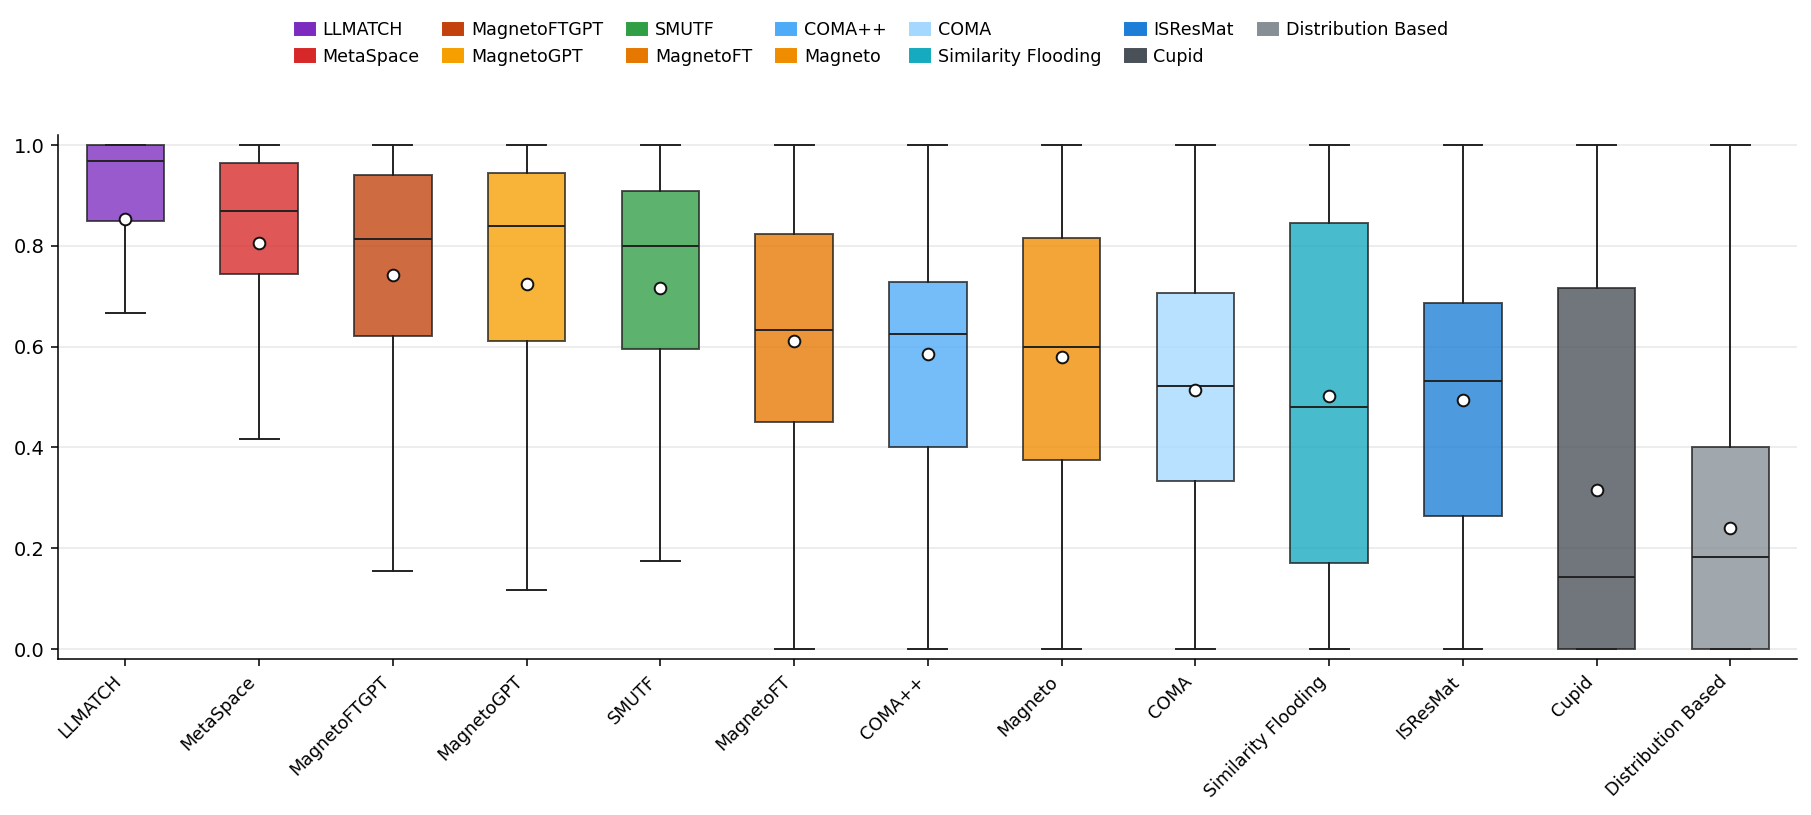

,method,mean_f1,std_f1,n_pairs
5,LLMATCH,0.85,0.25,551
10,MetaSpace,0.81,0.24,551
8,MagnetoFTGPT,0.74,0.25,551
9,MagnetoGPT,0.72,0.29,551
11,SMUTF,0.72,0.27,551
7,MagnetoFT,0.61,0.27,551
1,COMA++,0.59,0.24,509
6,Magneto,0.58,0.29,551
0,COMA,0.51,0.26,544
12,Similarity Flooding,0.50,0.35,543


In [5]:
pair_f1 = pd.read_csv(OUT / "effectiveness_baselines_metaspace_by_pair.csv")
pair_f1 = pair_f1[pair_f1["method"].isin(PLOT_ORDER)].copy()
pair_f1["f1_all_to_all"] = pd.to_numeric(pair_f1["f1_all_to_all"], errors="coerce")
summary_order = (
    pair_f1.groupby("method")["f1_all_to_all"]
    .mean()
    .sort_values(ascending=False)
    .index.tolist()
)
methods = [m for m in summary_order if m in METHOD_PALETTE]
values = [pair_f1.loc[pair_f1["method"] == m, "f1_all_to_all"].dropna().to_numpy() for m in methods]

fig, ax = plt.subplots(figsize=(13.5, 7.2))
box = ax.boxplot(values, patch_artist=True, showfliers=False, widths=0.58)
for patch, method in zip(box["boxes"], methods):
    patch.set_facecolor(method_color(method))
    patch.set_alpha(0.78)
    patch.set_edgecolor("#222222")
for key in ["whiskers", "caps", "medians"]:
    for artist in box[key]:
        artist.set_color("#222222")
        artist.set_linewidth(1.0)

means = [np.mean(v) if len(v) else np.nan for v in values]
ax.scatter(np.arange(1, len(methods) + 1), means, color="white", edgecolor="#111111", s=36, zorder=3, label="Mean")
ax.set_xticks(np.arange(1, len(methods) + 1))
ax.set_xticklabels(methods, rotation=45, ha="right")
ax.set_ylim(-0.02, 1.02)
ax.set_ylabel("")
ax.grid(axis="y", alpha=0.28)
ax.grid(axis="x", visible=False)

handles = legend_for_methods(methods)
fig.legend(
    handles=handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.94),
    ncol=7,
    frameon=False,
    columnspacing=1.35,
    handlelength=1.15,
    handletextpad=0.45,
    borderaxespad=0.0,
)
fig.subplots_adjust(top=0.82, bottom=0.30, left=0.07, right=0.99)
save_fig(fig, "plot_distribution_f1_all_to_all_by_method_matplotlib")
plt.show()

display(
    pair_f1.groupby("method", as_index=False)
    .agg(mean_f1=("f1_all_to_all", "mean"), std_f1=("f1_all_to_all", "std"), n_pairs=("pair_id", "nunique"))
    .sort_values("mean_f1", ascending=False)
    .round(2)
)


## 4. Runtime Distribution by Table Pair


Saved: /Users/nahawandkired/Documents/metamatch/outputs/exp_occidata/reports/meeting_baselines_vs_metamatch/rq1_effectiveness_efficiency/plot_distribution_runtime_by_method_matplotlib.png
Saved: /Users/nahawandkired/Documents/metamatch/outputs/exp_occidata/reports/meeting_baselines_vs_metamatch/rq1_effectiveness_efficiency/plot_distribution_runtime_by_method_matplotlib.pdf


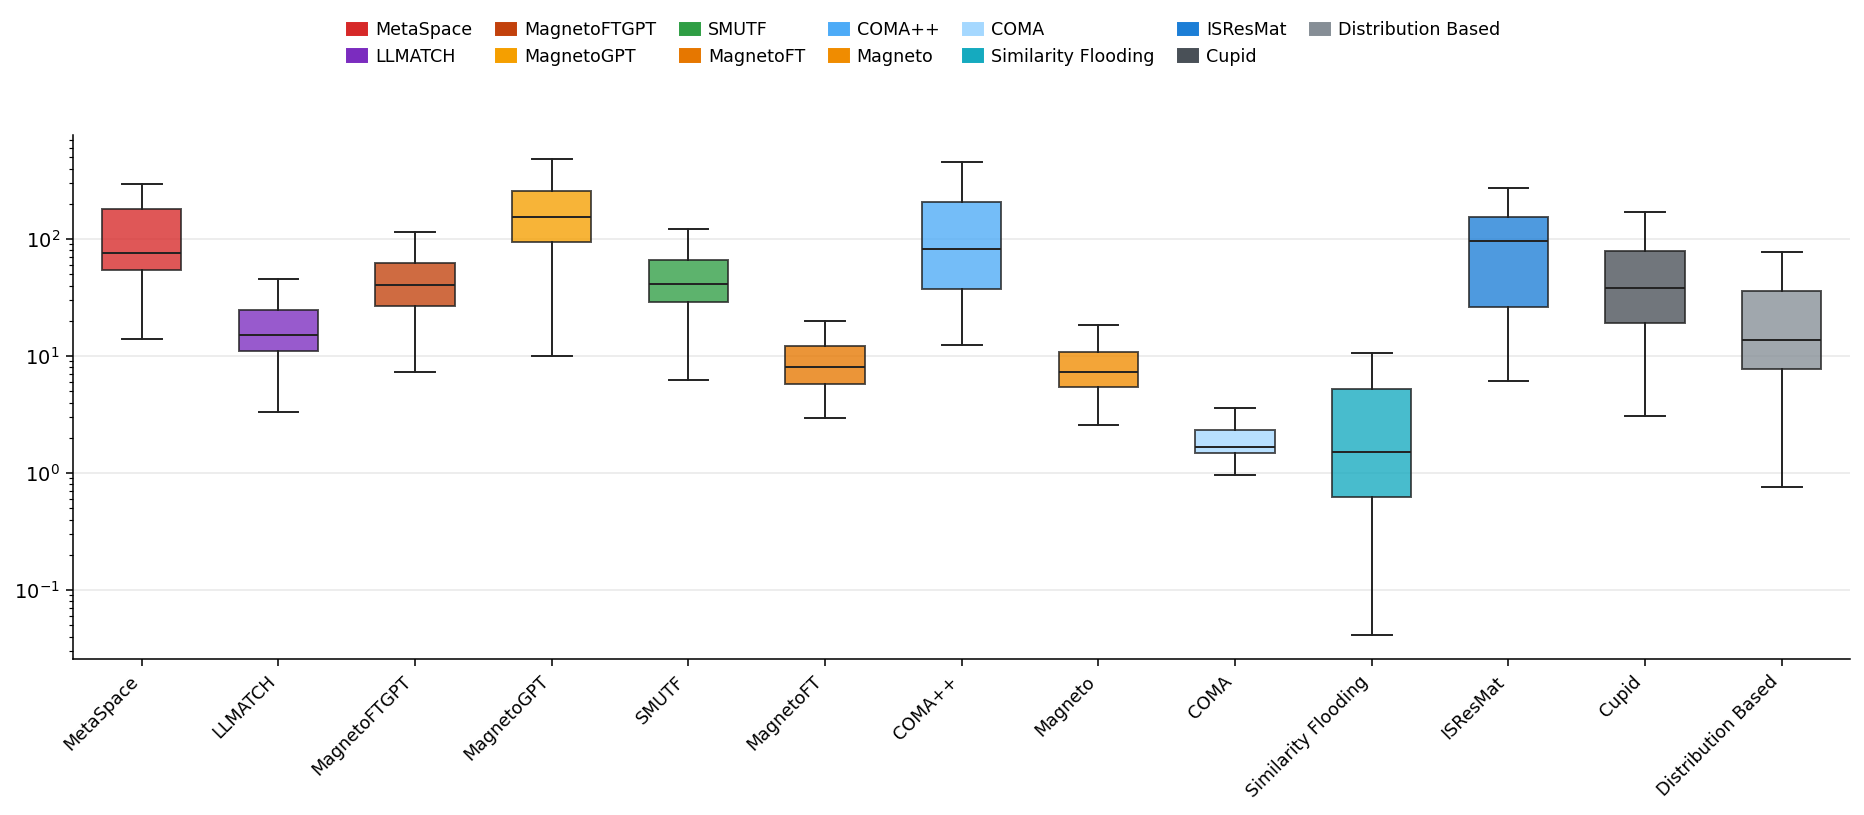

In [6]:

runtime_df = pd.read_csv(OUT / "efficiency_runtime_by_pair.csv")
runtime_df = runtime_df[runtime_df["method"].isin(PLOT_ORDER)].copy()
runtime_df["runtime_sec_pair"] = pd.to_numeric(runtime_df["runtime_sec_pair"], errors="coerce")

runtime_methods = [m for m in PLOT_ORDER if m in runtime_df["method"].unique()]
runtime_values = [
    runtime_df.loc[runtime_df["method"] == m, "runtime_sec_pair"].dropna().to_numpy()
    for m in runtime_methods
]
nonempty = [(m, v) for m, v in zip(runtime_methods, runtime_values) if len(v)]
runtime_methods = [m for m, _ in nonempty]
runtime_values = [v for _, v in nonempty]

fig, ax = plt.subplots(figsize=(13.5, 7.2))
box = ax.boxplot(runtime_values, patch_artist=True, showfliers=False, widths=0.58)
for patch, method in zip(box["boxes"], runtime_methods):
    patch.set_facecolor(method_color(method))
    patch.set_alpha(0.78)
    patch.set_edgecolor("#222222")
for key in ["whiskers", "caps", "medians"]:
    for artist in box[key]:
        artist.set_color("#222222")
        artist.set_linewidth(1.0)

ax.set_xticks(np.arange(1, len(runtime_methods) + 1))
ax.set_xticklabels(runtime_methods, rotation=45, ha="right")
ax.set_yscale("log")
ax.set_xlabel("")
ax.set_ylabel("")
ax.grid(axis="y", alpha=0.28)
ax.grid(axis="x", visible=False)

handles = legend_for_methods(runtime_methods)
fig.legend(
    handles=handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.94),
    ncol=7,
    frameon=False,
    columnspacing=1.35,
    handlelength=1.15,
    handletextpad=0.45,
    borderaxespad=0.0,
)
fig.subplots_adjust(top=0.82, bottom=0.30, left=0.05, right=0.99)
save_fig(fig, "plot_distribution_runtime_by_method_matplotlib")
plt.show()

runtime_df.to_csv(OUT / "figure_4_distribution_application_runtime_by_pair.csv", index=False)
runtime_df.to_csv(OUT / "companion_site_csv/figure_4_distribution_application_runtime_by_pair.csv", index=False)


## 5. Efficiency Table: Preliminary Computation vs. Application

This table separates offline/preliminary computation from application time over the 551 table pairs. Final companion-site CSV files are exported under `companion_site_csv/`, with one CSV per table or figure.


In [7]:
# Corrected table: MetaSpace RF no longer uses the old 7031s training total.
# RF training is recalibrated from a real fold_0 run: 50.59s for 260706 training rows, then scaled over the 6 folds.
# RF application is predict_proba only on all test rows over the 6 folds: 3.76s.

csv_path = OUT / "table_efficiency_preliminary_application_total_551_pairs.csv"
companion_path = OUT / "companion_site_csv/table_2_efficiency_preliminary_application_total_551_pairs.csv"

# Regenerate companion CSV files from the source script if needed:
# /Users/nahawandkired/Documents/metamatch/.venv/bin/python3 scripts/build_rq1_companion_csvs.py

efficiency_split = pd.read_csv(csv_path)
efficiency_split = efficiency_split[efficiency_split["method"].isin(PLOT_ORDER)].copy()
efficiency_split["preliminary_computation"] = efficiency_split["preliminary_computation"].replace({"61 meta-features construction + RF training": "60 meta-features construction + RF training"})

cols_display = [
    "method",
    "preliminary_computation",
    "preliminary_time_sec",
    "application_time_sec_551_pairs",
    "known_total_time_sec_551_pairs",

]

efficiency_split_paper = efficiency_split[cols_display].copy()
efficiency_split_paper = efficiency_split_paper.rename(columns={
    "method": "Method",
    "preliminary_computation": "Preliminary computation",
    "preliminary_time_sec": "Preliminary time (s)",
    "application_time_sec_551_pairs": "Application time (s)",
    "known_total_time_sec_551_pairs": "Total time (s)",

})
efficiency_split_paper = efficiency_split_paper.fillna(0)
for col in ["Preliminary time (s)", "Application time (s)", "Total time (s)"]:
    efficiency_split_paper[col] = efficiency_split_paper[col].round(2)

tex_path = OUT / "table_efficiency_preliminary_application_total_551_pairs_latex.tex"
efficiency_split_paper.to_latex(tex_path, index=False, escape=False, na_rep="/")

display(efficiency_split_paper)
print("Saved:", csv_path)
print("Saved:", companion_path)
print("Saved:", tex_path)




,Method,Preliminary computation,Preliminary time (s),Application time (s),Total time (s)
0,MetaSpace,60 meta-features construction + RF training,66565.13,3.76,66568.89
1,LLMATCH,/,0.00,10540.86,10540.86
2,SMUTF,XGBoost fine-tuning,7977.31,15.60,7992.91
3,MagnetoFTGPT,fine-tuning,306456.07,23410.89,329866.96
4,MagnetoFT,fine-tuning,306456.07,7199.53,313655.60
5,MagnetoGPT,/,0.00,25718.39,25718.39
6,Magneto,/,0.00,7659.29,7659.29
7,ISResMat,/,0.00,67788.31,67788.31
8,COMA++,/,0.00,71928.14,71928.14
9,COMA,/,0.00,1081.49,1081.49


Saved: /Users/nahawandkired/Documents/metamatch/outputs/exp_occidata/reports/meeting_baselines_vs_metamatch/rq1_effectiveness_efficiency/table_efficiency_preliminary_application_total_551_pairs.csv
Saved: /Users/nahawandkired/Documents/metamatch/outputs/exp_occidata/reports/meeting_baselines_vs_metamatch/rq1_effectiveness_efficiency/companion_site_csv/table_2_efficiency_preliminary_application_total_551_pairs.csv
Saved: /Users/nahawandkired/Documents/metamatch/outputs/exp_occidata/reports/meeting_baselines_vs_metamatch/rq1_effectiveness_efficiency/table_efficiency_preliminary_application_total_551_pairs_latex.tex


## 6. RQ2/RQ3: Ablation and Feature Selection

Train-only pair-level threshold strategy, same Random Forest setting.


In [ ]:
from IPython.display import display, Image
RQ23_OUT = Path("/Users/nahawandkired/Documents/metamatch/outputs/exp_occidata/reports/meeting_baselines_vs_metamatch/rq2_rq3_ablation_feature_selection_rf350")

rq2_table = pd.read_csv(RQ23_OUT / "rq2_family_ablation_for_paper.csv")
rq3_table = pd.read_csv(RQ23_OUT / "rq3_full_vs_compact_for_paper.csv")
rq3_efficiency = pd.read_csv(RQ23_OUT / "rq3_full_vs_compact_efficiency_end_to_end_compact_measured.csv")

display(rq2_table)
display(Image(filename=str(RQ23_OUT / "fig_rq2_family_ablation_f1.png")))

display(rq3_table)
display(Image(filename=str(RQ23_OUT / "fig_rq3_full_vs_compact_f1.png")))

display(rq3_efficiency)


## Statistical Tests: MetaSpace vs Baselines

Paired one-sided Wilcoxon signed-rank tests over common table pairs, with Holm correction for multiple comparisons. The test checks whether MetaSpace has higher pair-level all-to-all F1 than each baseline.


In [ ]:
stats_path = OUT / "rq1_metaspace_vs_baselines_paired_stat_tests_paper.csv"
stats_df = pd.read_csv(stats_path)
display(stats_df)
print("CSV:", OUT / "rq1_metaspace_vs_baselines_paired_stat_tests.csv")
print("LaTeX:", OUT / "rq1_metaspace_vs_baselines_paired_stat_tests_latex_compact.tex")
